#### **7PAM2016-0105-2024 -- Advanced Research Topics in Data Science**
##### Time Series Modelling Case Study - on Johnson & Johnson's Sales Data
---
**Mohit Agarwal (Student ID-22031257)**

Forecasting Sale Data for the next 24 months. The sales are recorded from Jan 1960 to Oct 1980, with 3 months interval, having 84 total entries.

In [3]:
# importing require packages...
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import boxcox
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

Changing the default styles and palettes

In [3]:
# setting style
sns.set_style("darkgrid")
# setting context
sns.set_context("paper")
# setting palette
sns.set_palette("deep", color_codes=True)

ADF-Test Functions

In [4]:
# function with adf test...
def adfuller_test(series):
    """ performs the ADF(Augmented Dickey-Fuller) test on the provided time-series for stationary, and 
    prints the test-statistic values, p-values, number of lags and observation used, and the critical 
    values. Finally it compares the p-values with significance level(0.05).

    Args:
        series: time series data to tested for stationary.
    """

    # performing the test for the gives series
    result = adfuller(series)
    labels = ["Test-Statistic", "p-value",
              "Number of Lags Used",
              "Number of Observations Used"]
    # printing the labels' values
    for value, label in zip(result, labels):
        print(label + " : " + str(value))
    # printing the critical values
    print("Critical Values:")
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    # comparing the p-values
    if result[1] <= 0.05:
        print("P value is less than 0.05 that means we can reject the null hypothesis(Ho).")
        print("--> Therefore we can conclude that data has no unit root and is stationary")
    else:
        print(
            "Weak evidence against null hypothesis that means time series has a unit root")
        print("--> Indicates the time series is non-stationary ")

Autocorrelation & Partial Autocorrelation Function

In [5]:
# function to plot autocorrelation and partial autocorrelation
def acf_pacf_plot(series, title):
    """ plots the autocorrelation and partial autocorrelation for the given series
    and saves them in the local working drive.

    Args:
        series: time-series data for ploting.
        title: plot super title.
    """

    # creating a subplots with 2 rows
    fig, ax = plt.subplots(ncols=1, nrows=2,
                           figsize=(8, 8), sharex=True)
    # plotting the autocorrelation of the data
    plot_acf(series, ax=ax[0])
    ax[0].set_ylabel("Autocorrelation")

    # plotting the partial autocorrelation of the data
    plot_pacf(series, ax=ax[1])
    ax[1].set_ylabel("Partial Autocorrelation")

    plt.xlabel("Lags")
    plt.suptitle(title, weight="bold")
    fig.tight_layout()
    plt.savefig(f"acf_pacf_{title}.png")
    plt.show()

ARIMA Function

In [6]:
def parameter_tune_arima(train, test, p=8, q=8):
    """ finds the best order, i.e p, and q for the given series using AIC and MSE,
    only valid for stationary series

    Args:
        train: stationary series for which best order needs to be optimized.
        test: for calcluating MSE.
        p: autoregress term, by default 8.
        q: moving average term, by default 8.

    Returns:
        df_result: a dataframe of AIC, MSE values with corresponding order as index.
    """

    # dict to track the AIC and MSE values
    result = {}
    # looping over p*q
    for i in range(p):
        for j in range(q):
            order = (i, 0, j)
            # defining the model
            model = ARIMA(train, order=order)
            model_fit = model.fit()
            # forecasting as long as test length
            forecast = model_fit.get_forecast(len(test)).predicted_mean
            # calculting mse
            mse = mean_squared_error(test, forecast)
            print(
                f"Order: {order} --> AIC: {model_fit.aic:7.3f} | MSE: {mse:7.3f}")
            result[order] = [model_fit.aic, mse]
    # converting result to dataframe
    df_result = pd.DataFrame.from_dict(
        result, orient="index", columns=["AIC", "MSE"])
    print("\n============================================\n")
    # finding the best order...
    best_order_aic = df_result.sort_values(by=["AIC"], ascending=True).index[0]
    best_order_mse = df_result.sort_values(by=["MSE"], ascending=True).index[0]
    print(
        f"The best order: {best_order_aic} with AIC: {result[best_order_aic][0]:7.3f}")
    print(
        f"The best order: {best_order_mse} with MSE: {result[best_order_mse][1]:7.3f}")

    return df_result

Reading the Johnson & Johnson sales file from the drive

In [7]:
# reading the file from the drive...
df_jj = pd.read_csv(
    r"D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\jj.csv")
df_jj.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


Looking at the info and description of the data

In [8]:
# looking at the info
print("\nThe info of the data is: \n", df_jj.info())
# looking at the description
print("\nThe description of the data is: \n", df_jj.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    84 non-null     object 
 1   data    84 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.4+ KB

The info of the data is: 
 None

The description of the data is: 
             data
count  84.000000
mean    4.799762
std     4.309991
min     0.440000
25%     1.247500
50%     3.510000
75%     7.132500
max    16.200000


The datetime is not in correct format, changing to datetime format using pandas's datatime and setting it as index.

In [9]:
# converting date to datetime format and setting it as index
df_jj.index = pd.to_datetime(
    df_jj.iloc[:, 0], yearfirst=True, infer_datetime_format=True)
df_jj.drop(columns="date", inplace=True)
df_jj.head()

,data
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61


In [10]:
# looking at the first and last date 
print("The First Data Entry Date: ", df_jj.index[0])
print("The Last Data Entry Date: ", df_jj.index[-1])

The First Data Entry Date:  1960-01-01 00:00:00
The Last Data Entry Date:  1980-10-01 00:00:00


Checking for null values

In [11]:
# checking for null values
df_jj.isna().sum()

data    0
dtype: int64

No Null values present.

Plotting the data

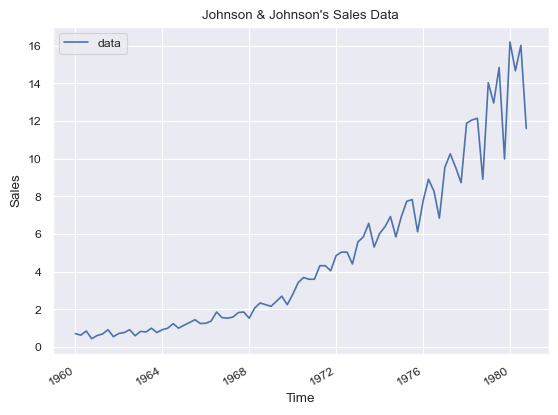

In [12]:
# plotting the data as line graph
df_jj.plot(xlabel="Time", ylabel="Sales",
           title="Johnson & Johnson's Sales Data")
plt.savefig("Johnson & Johnson's Sales Data.png")
plt.show()

The plot have a linear trend with seasonality(need to check) towards the end of the series, and it is non-stationary(need to check). 

### Check for Seasonality 

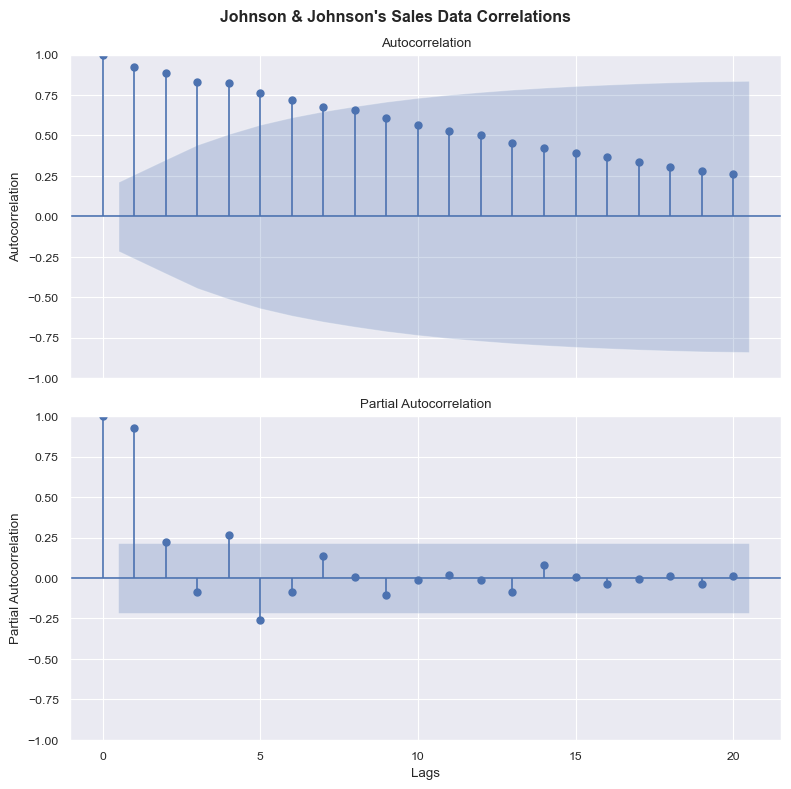

In [13]:
# plotting the autocorrelation and partial autocorrelation of the data
acf_pacf_plot(
    series=df_jj, title="Johnson & Johnson's Sales Data Correlations")

Autocorrelation and Partial-autocorrelation suggests there is seasonality, let check further through decomposing.

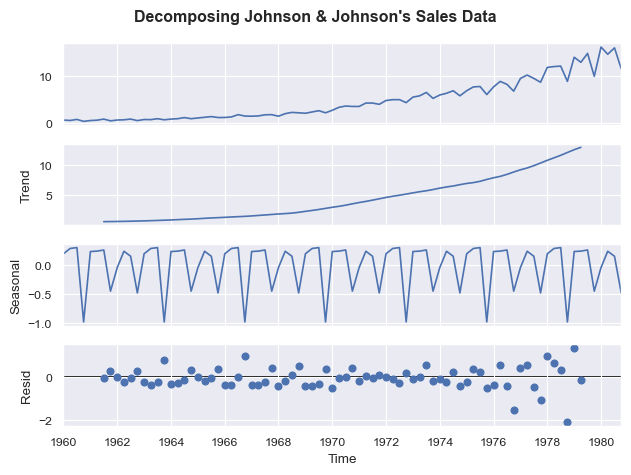

In [14]:
# decomposing the data with auunal period
decompose_data = seasonal_decompose(df_jj, model='additive', period=12)
decompose_data.plot()
plt.xlabel("Time")
plt.suptitle("Decomposing Johnson & Johnson's Sales Data", weight="bold")
plt.tight_layout()
plt.savefig("Decomposing Johnson & Johnson's Sales Data.png")
plt.show()

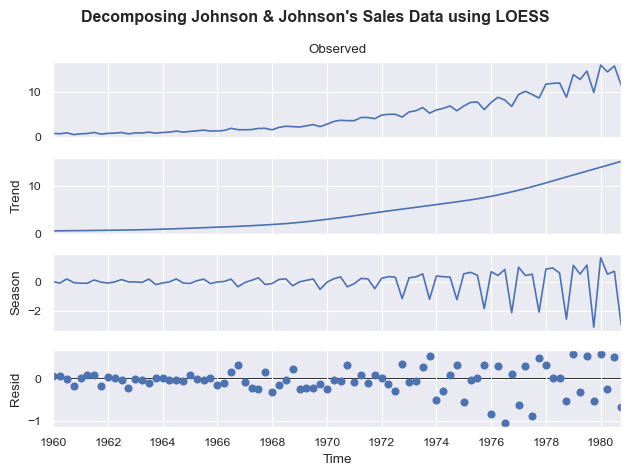

In [15]:
# decomposing with Season-Trend decomposition using LOESS.
from statsmodels.tsa.seasonal import STL
stl_decompose = STL(df_jj, period=12).fit()
stl_decompose.plot()
plt.xlabel("Time")
plt.suptitle(
    "Decomposing Johnson & Johnson's Sales Data using LOESS", weight="bold")
plt.tight_layout()
plt.savefig("Decomposing Johnson & Johnson's Sales Data using LOESS.png")
plt.show()

The time series sales data of Johnson and Johnson has seasonality, so we need to use moving average in the ARIMA part.

### Checking for Stationary

#### Stationary 
A time series is said to be stationary, if it's mean, variance and autocorrelation remains constant over time. 

#### Importance of Stationary
Most models, like ARMA, ARIMA are build on the assumption that the serie(s) are stationary in nature, allowing for meaningfull analysis and higher forcasting accuracy.

**Before performing any statistics test, let's transform the data and look at the Autocorrelation and Partial-Autocorrelation plots.**

In [15]:
# transforming the data using boxcox method...
df_jj["box_cox"], lmbda = boxcox(df_jj["data"])
print("Lambda: ", lmbda)
df_jj.head()

Lambda:  0.050710314712169455


,data,box_cox
date,,
1960-01-01,0.71,-0.339533
1960-04-01,0.63,-0.456665
1960-07-02,0.85,-0.161851
1960-10-01,0.44,-0.804126
1961-01-01,0.61,-0.488153


Plotting the transformed data

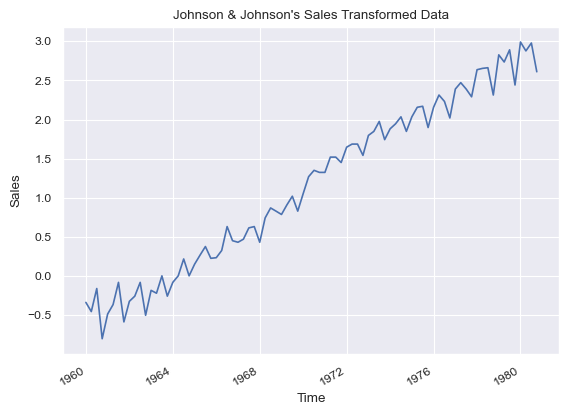

In [16]:
# plotting the transformed data as line graph
df_jj.iloc[:, 1].plot(xlabel="Time", ylabel="Sales",
                      title="Johnson & Johnson's Sales Transformed Data")
plt.show()

Ploting Autocorrelation and Partial-Autocorrelation plots.

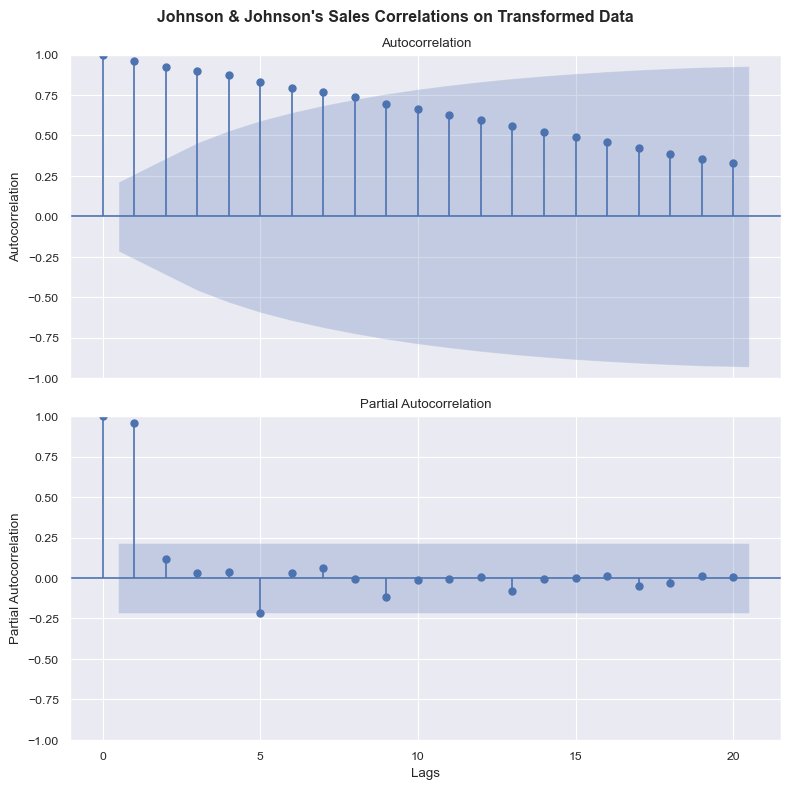

In [17]:
# plotting the autocorrelation and partial autocorrelation of the transformed data
acf_pacf_plot(
    series=df_jj.iloc[:, 1], title="Johnson & Johnson's Sales Correlations on Transformed Data")

The relationship between lagged values is still positive, so the transformed data is also non-stationary.

From the Autocorrelation and Partial-Autocorrelation, it's clear that the series is non-stationary, however confirmation of that with ADF(Augmented Dickey-Fuller) test will prove with statistics.

#### ADF(Augmented Dickey-Fuller) Test
The test for the presence of a unit root in a univariant seires.

**Null Hyposthesis (H<sub>0</sub>) :** Time-series has a unit root, i.e. **non-stationary**

**Alternative  Hyposthesis (H<sub>1</sub>) :** Time series does not has a unit root, i.e. **stationary**


##### Interpreting the test:
1. Test Statistic: Compares with the critical values; if more negative indicates rejection of H<sub>0</sub>.
2. p-value: p-value less than significance value(0.05) means rejecting H<sub>0</sub>.
3. Critical Values: Provided at 1%, 5% and 10% significance levels. 


In [18]:
# testing on the original series
adfuller_test(df_jj.iloc[:, 0])

Test-Statistic : 2.7420165734574735
p-value : 1.0
Number of Lags Used : 11
Number of Observations Used : 72
Critical Values:
	1%: -3.525
	5%: -2.903
	10%: -2.589
Weak evidence against null hypothesis that means time series has a unit root
--> Indicates the time series is non-stationary 


In [19]:
# testing on the transformed series
adfuller_test(df_jj.iloc[:, 1])

Test-Statistic : -0.302498032725871
p-value : 0.9251497901330838
Number of Lags Used : 4
Number of Observations Used : 79
Critical Values:
	1%: -3.516
	5%: -2.899
	10%: -2.587
Weak evidence against null hypothesis that means time series has a unit root
--> Indicates the time series is non-stationary 


**Both, the original and the transformed data are non-stationary.**

### Converting the series to Stationary
Done through differencing method.

#### **1<sup>st</sup> Order Differencing**

In [20]:
# first order differencing
df_jj["1st_order_diff"] = df_jj.iloc[:, 0].diff()
df_jj.head()

,data,box_cox,1st_order_diff
date,,,
1960-01-01,0.71,-0.339533,NaN
1960-04-01,0.63,-0.456665,-0.08
1960-07-02,0.85,-0.161851,0.22
1960-10-01,0.44,-0.804126,-0.41
1961-01-01,0.61,-0.488153,0.17


Plotting the 1<sup>st</sup> Order Differencing data.

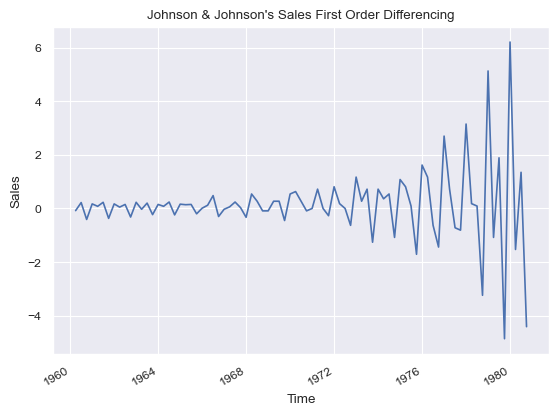

In [21]:
# plotting the 1st order diff...
df_jj["1st_order_diff"].plot(xlabel="Time",
                             ylabel="Sales",
                             title="Johnson & Johnson's Sales First Order Differencing")
plt.show()

Checking for Stationary 

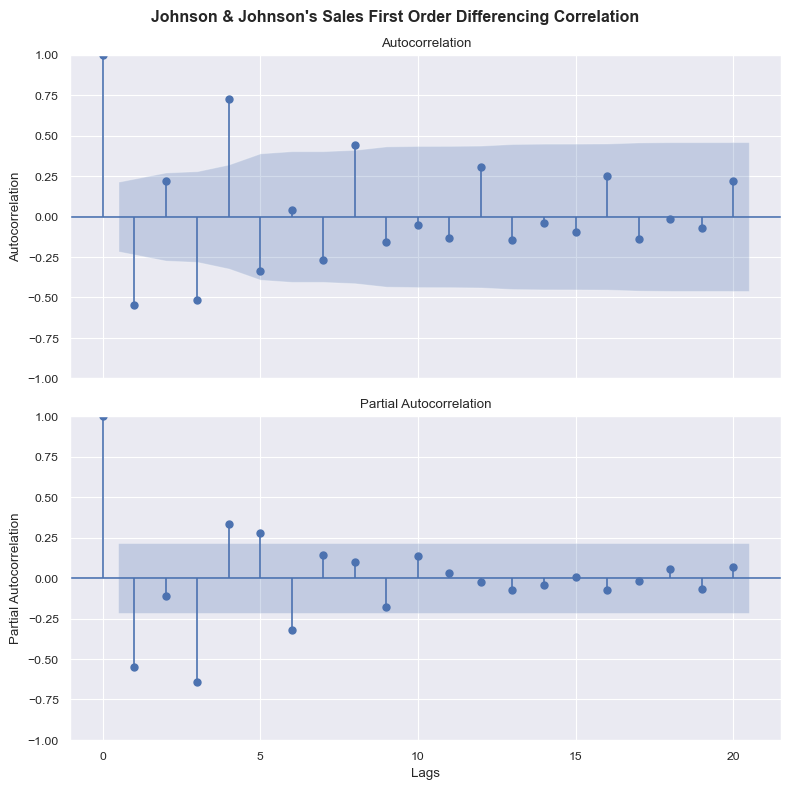

In [22]:
# looking at the acf and pacf plots...
acf_pacf_plot(series=df_jj.iloc[:, 2].dropna(),
              title="Johnson & Johnson's Sales First Order Differencing Correlation")

In [23]:
# looking at the adf-test...
adfuller_test(series=df_jj.iloc[:, 2].dropna())

Test-Statistic : -0.40740976363804116
p-value : 0.9088542416911313
Number of Lags Used : 10
Number of Observations Used : 72
Critical Values:
	1%: -3.525
	5%: -2.903
	10%: -2.589
Weak evidence against null hypothesis that means time series has a unit root
--> Indicates the time series is non-stationary 


#### **2<sup>nd</sup> Order Differencing**

In [24]:
# first order differencing
df_jj["2nd_order_diff"] = df_jj.iloc[:, 2].diff()
df_jj.head()

,data,box_cox,1st_order_diff,2nd_order_diff
date,,,,
1960-01-01,0.71,-0.339533,NaN,NaN
1960-04-01,0.63,-0.456665,-0.08,NaN
1960-07-02,0.85,-0.161851,0.22,0.30
1960-10-01,0.44,-0.804126,-0.41,-0.63
1961-01-01,0.61,-0.488153,0.17,0.58


Plotting the 2<sup>nd</sup> Order Differencing data.

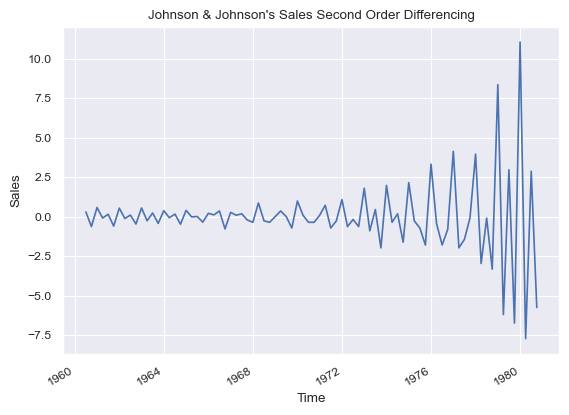

In [25]:
# plotting the 2nd order diff...
df_jj.iloc[:, 3].plot(xlabel="Time",
                      ylabel="Sales",
                      title="Johnson & Johnson's Sales Second Order Differencing")
plt.show()

Checking for Stationary 

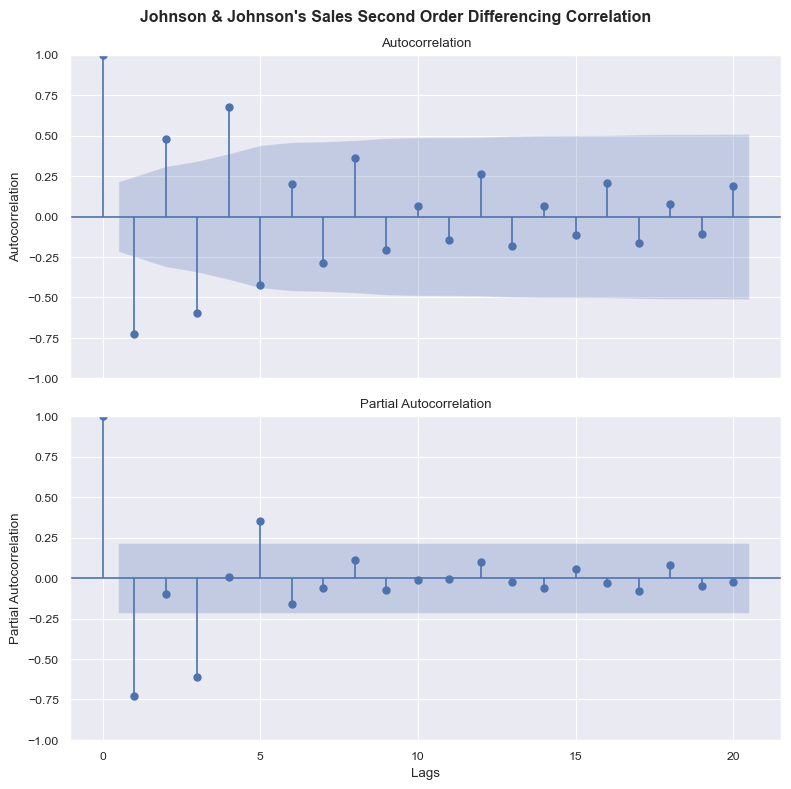

In [26]:
# looking at the acf and pacf plots...
acf_pacf_plot(series=df_jj.iloc[:, 3].dropna(),
              title="Johnson & Johnson's Sales Second Order Differencing Correlation")

In [27]:
# looking at the adf-test...
adfuller_test(series=df_jj.iloc[:, 3].dropna())

Test-Statistic : -3.585162874793187
p-value : 0.006051099869603033
Number of Lags Used : 9
Number of Observations Used : 72
Critical Values:
	1%: -3.525
	5%: -2.903
	10%: -2.589
P value is less than 0.05 that means we can reject the null hypothesis(Ho).
--> Therefore we can conclude that data has no unit root and is stationary


Second order differencing is stationary, building models based on that.

### ARIMA(Autoregressive Integrated Moving Average) Model
Forecasting method, combining three components:
1. Autoregression, p: Usage number of lagged, showing dependency b/w observed and lagged observation.
2. Integration, d: Differencing term, to make the series stationary. (d=2, in the Johnson & Johnson's Sales data)
3. Moving Avergae, q: Number of lagges forecast errors used, showing depencdency b/w observed and past forecast errors. Also soomths the short-term variation.

To select best parameter, Akaike Information Criterion (AIC) will be used.

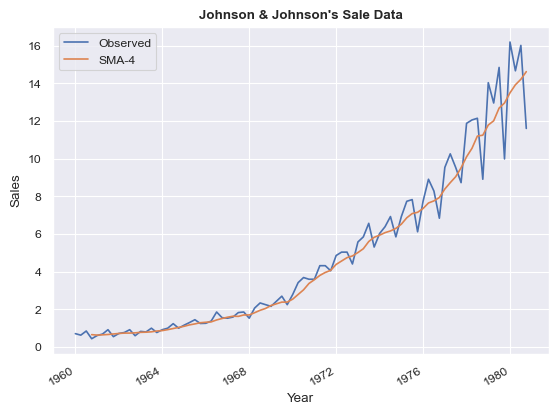

In [28]:
# moving average
df_jj.iloc[:, 0].plot(label="Observed")
df_jj.iloc[:, 0].rolling(4).mean().plot(xlabel="Year",
                                        ylabel="Sales",
                                        label="SMA-4")
plt.legend()
plt.title("Johnson & Johnson's Sale Data", weight="bold")
plt.show()

Splitting the series into train and test set.

In [29]:
# creating timeseries split object
tss = TimeSeriesSplit(n_splits=2)
# extracting the 2nd order differencing
x = df_jj.drop(labels=["data", "box_cox", "1st_order_diff"], axis=1).dropna()
# splitting the data
for train_index, test_index in tss.split(x):
    train, test = x.iloc[train_index, :], x.iloc[test_index, :]

In [30]:
# printing the length of the train and test sets
print("Length of Train-set: ", len(train))
print("Length of Test-set: ", len(test))

Length of Train-set:  55
Length of Test-set:  27


Plotting the train and test data.

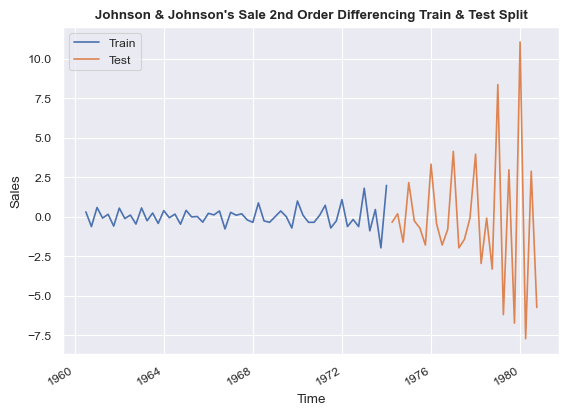

In [31]:
# ploting the train test data
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Sales")
plt.legend(["Train", "Test"])
plt.title(
    "Johnson & Johnson's Sale 2nd Order Differencing Train & Test Split", weight="bold")
plt.show()

Finding parameter for the ARIMA models

In [32]:
# finding the best order for 2nd order differencing
aic_mse_result = parameter_tune_arima(x, test)

Order: (0, 0, 0) --> AIC: 383.979 | MSE:  17.469
Order: (0, 0, 1) --> AIC: 301.029 | MSE:  18.409
Order: (0, 0, 2) --> AIC: 243.462 | MSE:  21.087
Order: (0, 0, 3) --> AIC: 214.354 | MSE:  24.007
Order: (0, 0, 4) --> AIC: 253.944 | MSE:  19.590
Order: (0, 0, 5) --> AIC: 204.507 | MSE:  20.637
Order: (0, 0, 6) --> AIC: 174.592 | MSE:  22.118
Order: (0, 0, 7) --> AIC: 171.065 | MSE:  24.861
Order: (1, 0, 0) --> AIC: 318.383 | MSE:  20.459
Order: (1, 0, 1) --> AIC: 268.768 | MSE:  22.125
Order: (1, 0, 2) --> AIC: 236.443 | MSE:  22.631
Order: (1, 0, 3) --> AIC: 256.517 | MSE:  25.455
Order: (1, 0, 4) --> AIC: 201.472 | MSE:  24.438
Order: (1, 0, 5) --> AIC: 174.310 | MSE:  24.551
Order: (1, 0, 6) --> AIC: 172.101 | MSE:  41.475
Order: (1, 0, 7) --> AIC: 161.679 | MSE:  42.404
Order: (2, 0, 0) --> AIC: 318.763 | MSE:  19.738
Order: (2, 0, 1) --> AIC: 267.872 | MSE:  21.583
Order: (2, 0, 2) --> AIC: 234.995 | MSE:  22.594
Order: (2, 0, 3) --> AIC: 248.195 | MSE:  21.418
Order: (2, 0, 4) -->

Finding parameter for the ARIMA models using Auto-ARIMA

In [33]:
# finding the order using auto-arima
auto_model = pm.auto_arima(y=x,
                           start_p=0, start_q=0,
                           max_p=8, max_q=8, m=12,
                           test="adf", stepwise=True,
                           trace=True, stationary=True,
                           seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=383.979, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=318.383, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=382.017, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=318.763, Time=0.34 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.66 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.12 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=316.440, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=316.822, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.57 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=268.110, Time=0.57 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=119.339, Time=1.93 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=1.35 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=118.218, Time=3.16 sec
 ARIMA

Checking Order 6, 0, 0

In [34]:
# defining arima with order 6, 0, 0
arima600 = ARIMA(x, order=(6, 0, 0))
model600 = arima600.fit()

In [35]:
# getting predictions
predict600 = model600.get_prediction(end=len(train)+len(test)-1)
predict600_df = pd.DataFrame(predict600.predicted_mean)

In [36]:
# extracting prediction of test length
predict600 = predict600_df.iloc[-len(test):, :].copy()
predict600.index = test.index

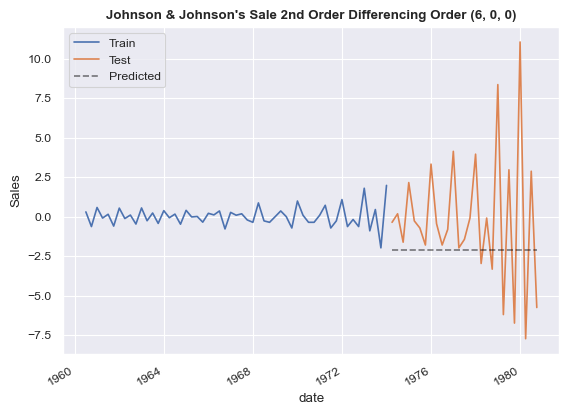

In [37]:
# ploting the train test data
_, ax = plt.subplots()
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Sales", ax=ax)
predict600.plot(ax=ax, linestyle="dashed", color="black", alpha=0.5)
plt.legend(["Train", "Test", "Predicted"])
plt.title(
    "Johnson & Johnson's Sale 2nd Order Differencing Order (6, 0, 0)", weight="bold")
plt.show()

In [38]:
# mse value of order 6, 0, 0
print(
    f"The MSE for Order (6, 0, 0): {mean_squared_error(test, predict600.values):.3f}")

The MSE for Order (6, 0, 0): 21.104


The MSE is very high and the predicted values from the graph is not even closed to the test values, as the moving average term was 0. The moving average term is important in this particular dataset as the ACF garphs showed highed correlation for first few lagged and dropped to zero. So, the order (6, 0, 0) can be rejected. 

Checking Order 6, 0, 1

In [39]:
# defining arima with order 6, 0, 1
arima601 = ARIMA(x, order=(6, 0, 1))
model601 = arima601.fit()

In [40]:
# getting predictions
predict = model601.get_prediction(end=len(train)+len(test)-1)
predict_df = pd.DataFrame(predict.predicted_mean)

In [41]:
# extracting prediction of test length
predict = predict_df.iloc[-len(test):, :].copy()
predict.index = test.index

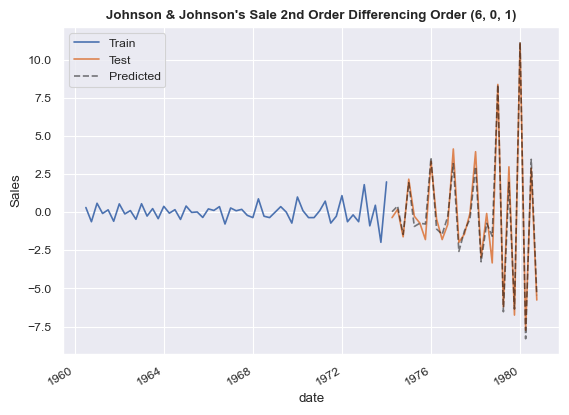

In [42]:
# ploting the train test data
_, ax = plt.subplots()
pd.concat([train, test], axis=1).plot(xlabel="Time", ylabel="Sales", ax=ax)
predict.plot(ax=ax, linestyle="dashed", color="black", alpha=0.5)
plt.legend(["Train", "Test", "Predicted"])
plt.title(
    "Johnson & Johnson's Sale 2nd Order Differencing Order (6, 0, 1)", weight="bold")
plt.show()

In [43]:
# mse value of order 6, 0, 0
print(
    f"The MSE for Order (6, 0, 1): {mean_squared_error(test, predict.values):.3f}")

The MSE for Order (6, 0, 1): 0.396


The MSE value for the order (6, 0, 1) has significatly lower than the one with order (6, 0, 0) and the predicted values are closed to the actual values which can be seen in the above graph. So, the order (6, 0, 1) can used to forecast the data for next 24 months.

In [44]:
print(model601.summary())

                               SARIMAX Results                                
Dep. Variable:         2nd_order_diff   No. Observations:                   82
Model:                 ARIMA(6, 0, 1)   Log Likelihood                 -52.912
Date:                Wed, 09 Apr 2025   AIC                            123.823
Time:                        23:56:19   BIC                            145.484
Sample:                             0   HQIC                           132.520
                                 - 82                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0049      0.001      3.575      0.000       0.002       0.008
ar.L1         -0.9798      0.227     -4.321      0.000      -1.424      -0.535
ar.L2         -0.3697      0.367     -1.008      0.3

[]

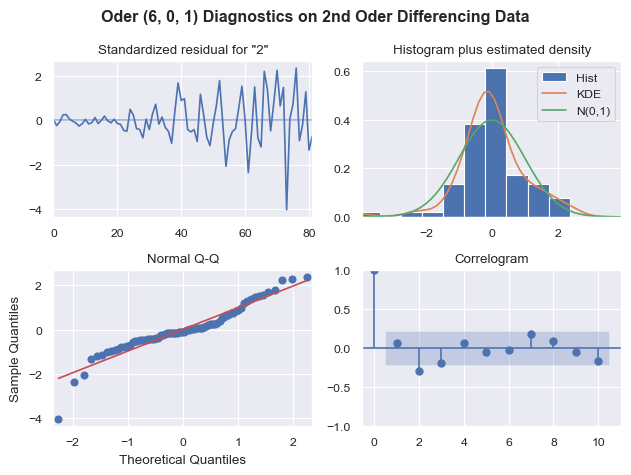

In [45]:
model601.plot_diagnostics()
plt.suptitle(
    "Oder (6, 0, 1) Diagnostics on 2nd Oder Differencing Data", weight="bold")
plt.tight_layout()
plt.plot()

Furthermore, from the diagnostics plot, it can seen that the residual is fluctuate around a mean of zero and have a uniform variance. The theoretical quantiles doesn't have any significat deviation implying the distribution is not skewed, which can be seen in the histogram plot, follows a normal distrinution with a little right shift. The correlogram does have some pattern.

Overall the model of order (6, 0, 1) seems a good fit.

### Forecasting For 24 Months with Roll Back - ARIMA
Roll Back means only one forecast is performed at a time, which is added to the original data at the end. The new data of original and forecasted data are again fitted to the model with the same parameter. This process is repeated n times, where n is the number of months.

The forecasting is said to done for next two years, which means number of steps for forecast is 8, as the data given is 3 months apart, i.e. 24/3 = 8.

In [46]:
# importing the datetime package...
import datetime
# number of forecast months
months = 24
# taking copy of original data
x = df_jj.drop(labels=["box_cox", "1st_order_diff",
                       "2nd_order_diff"], axis=1).dropna().copy()
# keeping track of CI
forecast_conf_int = {}
# keeping track of forecasted dates
forecast_dates = []
# forecasting with roll back..
for i in range(int(months/3)):
    # building the arima with p=6, d=2, q=1;
    # d=2, as using original data
    arima = ARIMA(x, order=(6, 2, 1))
    model = arima.fit()
    # forecasting the date - one step
    date = x.index[-1]
    if date.month == 10:
        date += datetime.timedelta(92)
    else:
        date += datetime.timedelta(91)
    forecast_dates.append(date)
    # getting one step forecast from the model
    forecast = model.get_forecast()
    # tracking the CI for the forecast into a dict
    if bool(forecast_conf_int) == False:
        forecast_conf_int = forecast.conf_int(alpha=0.5).to_dict()
    else:
        for key in forecast_conf_int.keys():
            forecast_conf_int[key].update(
                forecast.conf_int(alpha=0.5).to_dict()[key])
    # adding the forecasted data to the original data.
    x.reset_index(inplace=True)
    x.loc[len(x)] = [pd.Timestamp(date), forecast.predicted_mean.iloc[0]]
    x.set_index("date", drop=True, inplace=True)

In [47]:
# converting the CI dict to dataframe with forecasted dates as index
forecast_conf_int_df = pd.DataFrame.from_dict(forecast_conf_int)
forecast_conf_int_df["date"] = forecast_dates
forecast_conf_int_df.set_index("date", inplace=True)

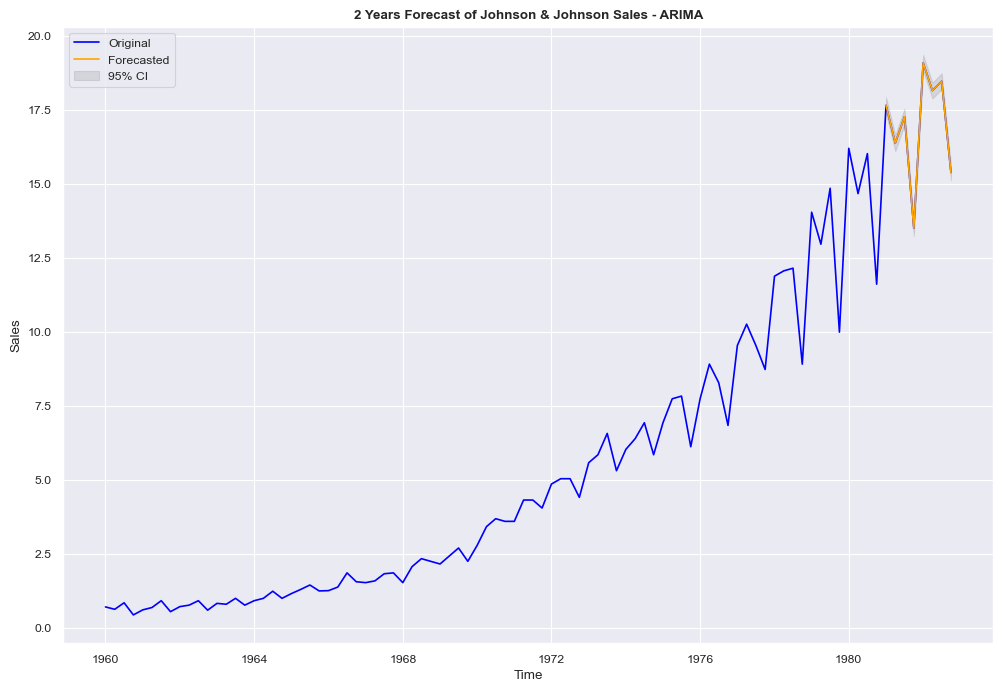

In [48]:
# plotting the forecasted data along the original data
n_forecast = 8
fig = plt.figure(figsize=(12, 8), dpi=100)
plt.plot(x['data'], 'blue', label="Original")
plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
# plotting the confidence interval
plt.fill_between(forecast_conf_int_df.index,
                 forecast_conf_int_df["lower data"],
                 forecast_conf_int_df["upper data"],
                 color="k", alpha=0.1, label="95% CI")
# adding title and labels
plt.title("2 Years Forecast of Johnson & Johnson Sales - ARIMA", weight="bold")
plt.xlabel("Time")
plt.ylabel("Sales")
# adding legend
plt.legend()
plt.savefig("2 Years Forecast of Johnson & Johnson Sales - ARIMA.png", dpi=300)
plt.show()

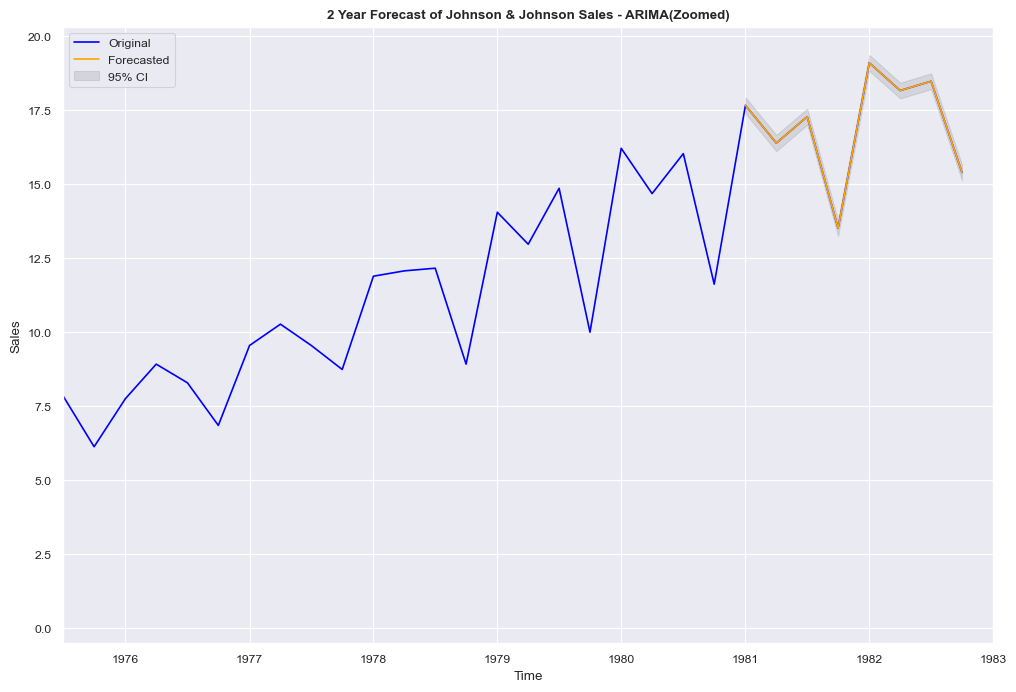

In [49]:
n_forecast = 8
fig = plt.figure(figsize=(12, 8), dpi=100)
plt.plot(x['data'], 'blue', label="Original")
plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
# plotting the confidence interval
plt.fill_between(forecast_conf_int_df.index,
                 forecast_conf_int_df["lower data"],
                 forecast_conf_int_df["upper data"],
                 color="k", alpha=0.1, label="95% CI")
# adding title and labels
plt.title("2 Year Forecast of Johnson & Johnson Sales - ARIMA(Zoomed)", weight="bold")
plt.xlabel("Time")
plt.ylabel("Sales")
# adding legend
plt.legend()
plt.xlim([x.index[-30], pd.DatetimeIndex(["1983-01-01"])])
plt.savefig(
    "Zoomed 2 Year Forecast of Johnson & Johnson Sales - ARIMA.png", dpi=300)
plt.show()

### Fourier Transform
Breaking down the series in simple forms of sins and cosins.

In [ ]:
# for fourier...
from scipy.fft import fft, fftfreq
import scipy as sp

In [87]:
# fourier transform 
ft = fft(df_jj.loc[:, "data"].values)
# getting the psd -- need to take square of abs
psd = np.abs(ft)**2
# getting frequency related to psd for a year
ft_freq = fftfreq(len(psd), 1. / 12)
# keeping positive freq
i = ft_freq > 0

# cutting off higher freq than fundamental ones
fft_bis = np.copy(ft)
fft_bis[np.abs(ft_freq) > 1.1] = 0

# inversing the fourier to single
inverse_series = np.real(sp.fftpack.ifft(fft_bis))

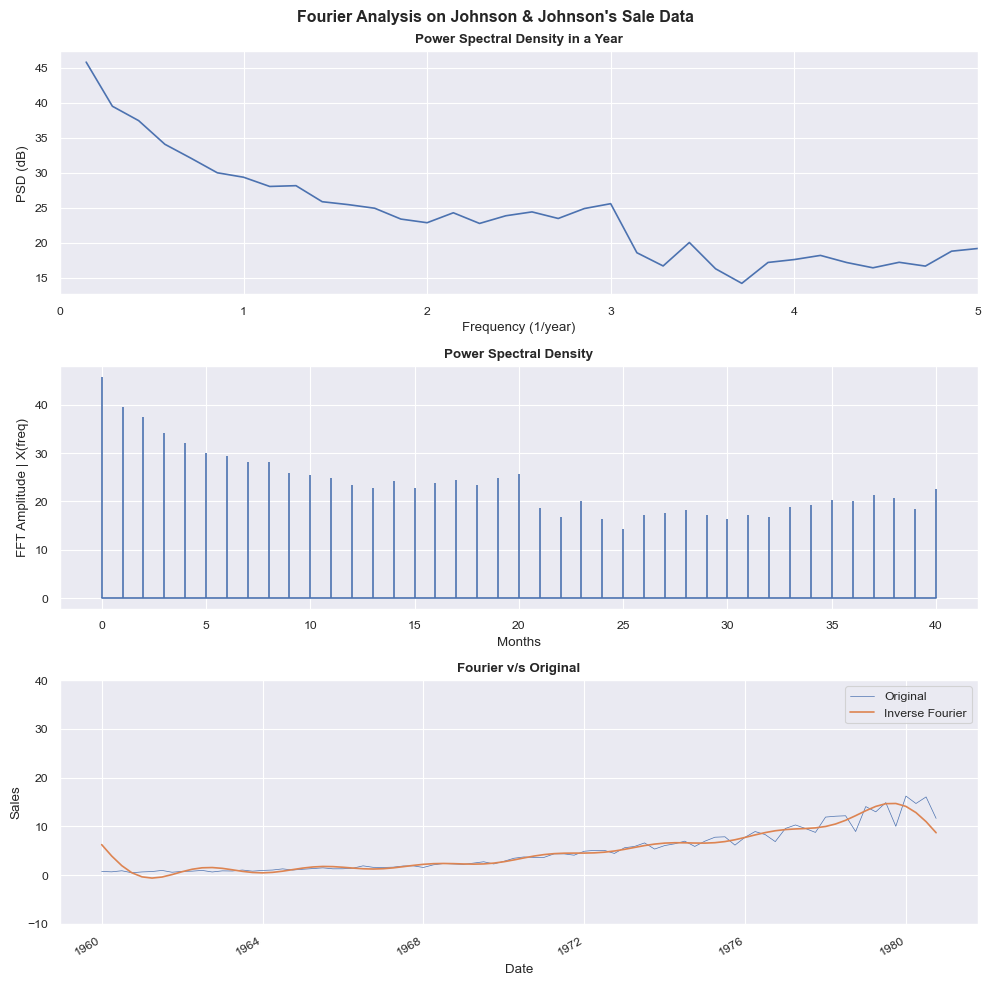

In [99]:
# plotting the fourier analyis 
fig, ax = plt.subplots(3, figsize=(10, 10))

ax[0].plot(ft_freq[i], 10 * np.log10(psd[i]))
ax[0].set_xlim(0, 5)
ax[0].set_xlabel('Frequency (1/year)')
ax[0].set_ylabel('PSD (dB)')
ax[0].set_title("Power Spectral Density in a Year", weight="bold")

ax[1].stem(10 * np.log10(psd[i]), "b", markerfmt=" ", basefmt="-b")
ax[1].set_xlabel("Months")
ax[1].set_ylabel("FFT Amplitude | X(freq)")
ax[1].set_title("Power Spectral Density", weight="bold")

df_jj.loc[:, "data"].plot(ax=ax[2], lw=.5, legend=True, label="Original")
ax[2].plot_date(df_jj.index, inverse_series, '-', label="Inverse Fourier")
ax[2].set_ylim(-10, 40)
ax[2].set_xlabel("Date")
ax[2].set_ylabel("Sales")
ax[2].set_title("Fourier v/s Original", weight="bold")
ax[2].legend()

plt.suptitle("Fourier Analysis on Johnson & Johnson's Sale Data", weight="bold")
plt.tight_layout()
plt.savefig("Fourier Analysis on Johnson & Johnson's Sale Data.png")

### Recurrent Neural Network Forcasting

RNN are used for sequential(dependent) data training, used for language modeling, translation, time series prediction, which is we are interested in. RNN contains a hidden states and loops, which allows the network to store pass information in this hidden state and operate as sequences, [Taken from here](https://www.mathworks.com/discovery/rnn.html).

RNN suffer from vanishing/exploding gradient problems training, that's why we are going to be using it's variant, namely LSTM and GRU for training and forecasting.

### Long Short-Term Memory (LSTM)
The flow of infromation in the LSTM is controlled by gates,
1. Forget Gate: decides which information to discard
2. Input Gate: decides which new information to pass
3. Output Gate: decides which part of the current cell state to be passed to next hidden state
activate by sigmoid function, and the state usage tanh function(0-1).

### Gated Recurrent Unit (GRU)
The flow of information is also controlled by gates, but in this case it has only two,
1. Update Gate: how much of the previous state to be used
2. Reset Gate: how much of the previous state to be forgetten.

In [50]:
# importing required packages...
import os
import keras
import keras_tuner
from sklearn.preprocessing import MinMaxScaler

In [51]:
# path to save the images and the training process
path = r"D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2"

#### Feature Engineering Sales Data

Creating lagged variables using shift operater for traning the recurrent neural network.

In [ ]:
def feature_engineering(data, no_lagged=7, split=False):
    """creates a lagged variables upto given numbers minus one, default to 7
    and add the moving average of size 4, along with trend, seasonal, and
    residual part of the series and option to split the data 
    into train and test sets

    Args:
        data: dataframe for producing laggied variabels
        no_lagged: number of laggied variables
            defult- 7
        split: bool variable for splitting into train-test set

    Returns:
        x, y: if split is false, lagged variables, traget
        x_train, x_test, y_train, y_test: if split is true, train-test sets
    """

    # creating lagged data
    df_features = data.loc[:, "data"].shift([i for i in range(1, no_lagged)])
    # decomposing the data
    decompose_data = seasonal_decompose(data.loc[:, "data"], 
                                        model='additive', period=12)
    # adding seasonal part
    df_features["season"] = decompose_data.seasonal.values
    # adding trend part
    df_features["trend"] = decompose_data.trend.values
    # adding residual part
    df_features["resid"] = decompose_data.resid.values
    # adding rolling mean of 4
    df_features["ma_4"] = data.loc[:, "data"].rolling(4).mean()

    # adding fourier features using fft
    # fft_values = fft(data.loc[:, "data"].values)
    # fft_magnitudes = np.abs(fft_values[:len(data)//2])

    # top_indices = np.argsort(fft_magnitudes)[-10:]
    # for i, idx in enumerate(top_indices):
    #     df_features[f"fft_freq_{i}"] = 0
    #     # Add the FFT component across the entire series as a feature
    #     df_features[f"fft_freq_{i}"] = np.real(fft_values[idx]) * np.cos(2 * np.pi * idx * np.arange(len(data)) / len(data)) + \
    #         np.imag(fft_values[idx]) * np.sin(2 * np.pi *
    #                                           idx * np.arange(len(data)) / len(data))

    # adding original data in the feature space
    df_features["data"] = data.loc[:, "data"]
    # dropping the null values
    df_features.dropna(inplace=True)
    # getting features and traget variables fromt 
    x = df_features.drop(columns="data")
    y = df_features.loc[:, "data"]

    if not split:
        # reshaping the data  to fit the model
        x = x.values.reshape((x.shape[0], 1, x.shape[1]))
        return x, y.values
    else:
        # splitting the data
        # for train_index, test_index in tss.split(x):
        #     x_train, x_test = x.iloc[train_index,
        #                              :].values, x.iloc[test_index, :].values
        #     y_train, y_test = y.iloc[train_index].values, y.iloc[test_index].values
        x_train, x_test = x.loc[x.index[:-8],
                                    :].values, x.loc[x.index[-8:], :].values
        y_train, y_test = y.loc[x.index[:-8]].values, y.loc[x.index[-8:]].values
        # reshaping the data  to fit the model
        x_train = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
        x_test = x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))
      
        return x_train, x_test, y_train, y_test

#### Model Class

Creating vanilla LSTM, vanilla GRU and stacked LSTM-GRU archeticture for training and forecasting. 

##### Vanilla LSTM Hypermodel Class
Two stacked LSTM layers with third LSTM layer as a hyperparameter.

In [54]:
class vanilla_lstm_hypermodel(keras_tuner.HyperModel):
    """vanilla lstm hypermodel build for hyperparameter optimization
    """

    def __init__(self, activations=["tanh", "sigmoid", "relu"]):
        """initializing the parameters for the model architecture 

        Args:
            activations: list of activation functions
                default- tanh, sigmoid, relu
        """

        super().__init__()
        self.activations = activations

    def build(self, hp):
        """builds the hypermodel for the vanilla lstm model 
        and compiles it

        Args:
            hp: hyperparameter method

        Returns:
            the compiles hypermodel
        """
        # clearing the pervious session of keras
        keras.backend.clear_session()
        # creating model
        model = keras.models.Sequential()
        # adding lstm layer to the model
        model.add(keras.layers.LSTM(hp.Int("lstm_units1",
                                           min_value=25,
                                           max_value=300,
                                           step=5),
                                    return_sequences=True,
                                    activation=hp.Choice("activation1",
                                                         values=self.activations)))
        # adding a dropout layer as hyperparameter
        if hp.Boolean("dropout1"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate1",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a second lstm layer as hyperparameter
        if hp.Boolean("lstm"):
            model.add(keras.layers.LSTM(hp.Int("lstm_units2",
                                               min_value=15,
                                               max_value=150,
                                               step=5),
                                        return_sequences=True,
                                        activation=hp.Choice("activation2",
                                                             values=self.activations)))
            # adding a second dropout layer as hyperparameter
            if hp.Boolean("dropout2"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate2",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding a third lstm layer as hyperparameter
        if hp.Boolean("lstm1"):
            model.add(keras.layers.LSTM(hp.Int("lstm_units3",
                                               min_value=5,
                                               max_value=50,
                                               step=5),
                                        activation=hp.Choice("activation3",
                                                             values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding top layers
        model.add(keras.layers.Flatten())
        model.add(keras.layers.Dense(1))

        # learning rate
        lr = hp.Float("learning_rate", min_value=0.001,
                      max_value=0.02, sampling="log")
        # learning optimizer
        optimizer_dict = {
            "SGD": keras.optimizers.SGD(lr),
            "Adam": keras.optimizers.Adam(lr),
        }
        # choicing an optimizer
        optimizer = hp.Choice("optimizer",
                              values=["Adam", "SGD"])
        # compiling the model
        model.compile(optimizer=optimizer_dict[optimizer],
                      loss=keras.losses.MeanSquaredError(),
                      metrics=[keras.metrics.MeanAbsoluteError()])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """fits the complied hypermodel with
        batch_size as hyperparameter

        Returns: 
            the fit to hypermodel
        """

        return model.fit(*args,
                         shuffle=False,
                         batch_size=hp.Int("batch_size", min_value=8,
                                           max_value=256, step=16),
                         **kwargs)

##### Vanilla GRU Hypermodel Class
Two stacked GRU layers with third GRU layer as a hyperparameter.

In [55]:
class vanilla_gru_hypermodel(keras_tuner.HyperModel):
    """vanilla gru hypermodel build for hyperparameter optimization
    """

    def __init__(self, activations=["tanh", "sigmoid", "relu"]):
        """initializing the parameters for the model architecture 

        Args:
            activations: list of activation functions
                default- tanh, sigmoid, relu
        """

        super().__init__()
        self.activations = activations

    def build(self, hp):
        """builds the hypermodel for the vanilla lstm model 
        and compiles it

        Args:
            hp: hyperparameter method

        Returns:
            the compiles hypermodel
        """
        # clearing the pervious session of keras
        keras.backend.clear_session()
        # creating model
        model = keras.models.Sequential()
        # adding gru layer to the model
        model.add(keras.layers.GRU(hp.Int("gru_units1",
                                          min_value=25,
                                          max_value=300,
                                          step=5),
                                   return_sequences=True,
                                   activation=hp.Choice("activation1",
                                                        values=self.activations)))
        # adding a dropout layer as hyperparameter
        if hp.Boolean("dropout1"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate1",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a second gru layer as hyperparameter
        if hp.Boolean("gru1"):
            model.add(keras.layers.GRU(hp.Int("gru_units2",
                                              min_value=15,
                                              max_value=150,
                                              step=5),
                                       return_sequences=True,
                                       activation=hp.Choice("activation2",
                                                            values=self.activations)))
            # adding a second dropout layer as hyperparameter
            if hp.Boolean("dropout2"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate2",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding a third gru layer as hyperparameter
        if hp.Boolean("gru1"):
            model.add(keras.layers.GRU(hp.Int("gru_units3",
                                              min_value=5,
                                              max_value=50,
                                              step=5),
                                       activation=hp.Choice("activation3",
                                                            values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding top layers
        model.add(keras.layers.Flatten())
        model.add(keras.layers.Dense(1))

        # learning rate
        lr = hp.Float("learning_rate", min_value=0.001,
                      max_value=0.02, sampling="log")
        # learning optimizer
        optimizer_dict = {
            "SGD": keras.optimizers.SGD(lr),
            "Adam": keras.optimizers.Adam(lr),
        }
        # choicing an optimizer
        optimizer = hp.Choice("optimizer",
                              values=["Adam", "SGD"])
        # compiling the model
        model.compile(optimizer=optimizer_dict[optimizer],
                      loss=keras.losses.MeanSquaredError(),
                      metrics=[keras.metrics.MeanAbsoluteError()])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """fits the complied hypermodel with
        batch_size as hyperparameter

        Returns: 
            the fit to hypermodel
        """

        return model.fit(*args,
                         shuffle=False,
                         batch_size=hp.Int("batch_size", min_value=8,
                                           max_value=256, step=16),
                         **kwargs)

##### Stacked LSTM-GRU Hypermodel Class
Stacked LSTM-GRU layers with third LSTM and/or GRU layer as a hyperparameter.

In [56]:
class stacked_lstm_gru_hypermodel(keras_tuner.HyperModel):
    """stacked lstm-gru hypermodel build for hyperparameter optimization
    """

    def __init__(self, activations=["tanh", "sigmoid", "relu"]):
        """initializing the parameters for the model architecture 

        Args:
            activations: list of activation functions
                default- tanh, sigmoid, relu
        """

        super().__init__()
        self.activations = activations

    def build(self, hp):
        """builds the hypermodel for the vanilla lstm model 
        and compiles it

        Args:
            hp: hyperparameter method

        Returns:
            the compiles hypermodel
        """
        # clearing the pervious session of keras
        keras.backend.clear_session()
        # creating model
        model = keras.models.Sequential()
        # adding lstm layer to the model
        model.add(keras.layers.LSTM(hp.Int("lstm_units1",
                                           min_value=25,
                                           max_value=300,
                                           step=5),
                                    return_sequences=True,
                                    activation=hp.Choice("activation1",
                                                         values=self.activations)))
        # adding a dropout layer as hyperparameter
        if hp.Boolean("dropout1"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate1",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a gru layer
        model.add(keras.layers.GRU(hp.Int("gru_units1",
                                          min_value=15,
                                          max_value=150,
                                          step=5),
                                   return_sequences=True,
                                   activation=hp.Choice("activation2",
                                                        values=self.activations)))
        # adding a second dropout layer as hyperparameter
        if hp.Boolean("dropout2"):
            model.add(keras.layers.Dropout(rate=hp.Float("rate2",
                                                         min_value=0.2,
                                                         max_value=0.7,
                                                         step=0.025)))
        # adding a second lstm layer as hyperparameter
        if hp.Boolean("lstm"):
            model.add(keras.layers.LSTM(hp.Int("lstm_units1",
                                               min_value=10,
                                               max_value=50,
                                               step=5),
                                        return_sequences=True,
                                        activation=hp.Choice("activation3",
                                                             values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))

        # adding a second gru layer as hyperparameter
        if hp.Boolean("gru"):
            model.add(keras.layers.GRU(hp.Int("gru_units2",
                                              min_value=10,
                                              max_value=50,
                                              step=5),
                                       return_sequences=True,
                                       activation=hp.Choice("activation3",
                                                            values=self.activations)))
            # adding a third dropout layer as hyperparameter
            if hp.Boolean("dropout3"):
                model.add(keras.layers.Dropout(rate=hp.Float("rate3",
                                                             min_value=0.2,
                                                             max_value=0.7,
                                                             step=0.025)))
        # adding top layers
        model.add(keras.layers.Flatten())
        model.add(keras.layers.Dense(1))

        # learning rate
        lr = hp.Float("learning_rate", min_value=0.001,
                      max_value=0.02, sampling="log")
        # learning optimizer
        optimizer_dict = {
            "SGD": keras.optimizers.SGD(lr),
            "Adam": keras.optimizers.Adam(lr),
        }
        # choicing an optimizer
        optimizer = hp.Choice("optimizer",
                              values=["Adam", "SGD"])
        # compiling the model
        model.compile(optimizer=optimizer_dict[optimizer],
                      loss=keras.losses.MeanSquaredError(),
                      metrics=[keras.metrics.MeanAbsoluteError()])

        return model

    def fit(self, hp, model, *args, **kwargs):
        """fits the complied hypermodel with
        batch_size as hyperparameter

        Returns: 
            the fit to hypermodel
        """

        return model.fit(*args,
                         shuffle=False,
                         batch_size=hp.Int("batch_size", min_value=8,
                                           max_value=256, step=16),
                         **kwargs)

##### Hypermodel building function 
Searchs for the best parameter to minimize the validation loss

In [57]:
def hypermodel_build(hypermodel, x_train, x_test,
                     y_train, y_test, project_name,
                     directory=os.path.join(path, "HPO")):
    """searches best parameter for the given model using bayesian optimizer
    with val loss to be minimized.
    Args:
        hypermodel: hypermodel for which search to be performed
        x_train, x_test, y_train, y_test: train-test set data
        project_name: name of the search to be stored in local data
        directory: location of the search history

    Returns:
        tuner: tuner for the hypermodel
        best_parameter = best parameter for the model 
        model: model build on best parameter
    """

    # tuner based on bayesian optimizer
    tuner = keras_tuner.BayesianOptimization(hypermodel=hypermodel,
                                             objective="val_loss",
                                             max_trials=10,
                                             executions_per_trial=3,
                                             directory=directory,
                                             project_name=project_name,
                                             overwrite=True)

    print("The search space is: \n", tuner.search_space_summary())
    # searching for best parameter over given data
    tuner.search(x_train, y_train, epochs=10,
                 validation_data=(x_test, y_test))
    print("The summary for the search is:\n", tuner.results_summary())
    # extracting best parameter
    best_parameter = tuner.get_best_hyperparameters(num_trials=1)[0]

    print("============================")
    print("The best parameters are:\n", best_parameter.values)
    print("============================")

    return tuner, best_parameter, hypermodel.build(best_parameter)

##### Model training function
Training the model

In [58]:
def model_history(x, y,
                  x_val, y_val,
                  model,
                  batch_size,
                  epochs,
                  filename,
                  path=path):
    """trains the given model with validation set, and 
    saves the models and csv log file to the provided location

    Args:
        x: non-label training data
        y: label training data
        x_val: non-label validation data
        y_val: label validation data
        model: model to train
        batch_size : batch size training
        epochs: number of epochs to be runned
        path: location for the saving files
        filename: filename for checkpoints and csvlogger

    Returns:
        history: the training history
    """

    # checkpoints
    checkpoint = keras.callbacks.ModelCheckpoint(filepath=os.path.join(path,
                                                                       f"{filename}.keras"),
                                                 monitor="val_loss",
                                                 mode="min",
                                                 save_best_only=True)
    # csvlogger
    csvlog = keras.callbacks.CSVLogger(filename=os.path.join(path,
                                                             f"{filename}.csv"),
                                       separator=",",
                                       append=False)
    # fitting the model to the data
    history = model.fit(x=x, y=y,
                        validation_data=(x_val, y_val),
                        shuffle=False,
                        batch_size=batch_size,
                        epochs=epochs,
                        callbacks=[checkpoint, csvlog],
                        verbose=1)

    return history

Learning Curve Plot function

In [59]:
def plot_learning_curve(history, title, path=path):
    """plots line graphs for a trained model and 
    saves them in the given location"""

    # metrics used
    metrics = ["loss", "mean_absolute_error"]

    # looping over metrics and plotting each one
    for metric in metrics:
        plt.plot(history.history[metric])
        plt.plot(history.history[f"val_{metric}"])
        plt.legend(["Training", "Validation"])
        plt.title(f"{title} - {metric.capitalize()}")
        plt.xlabel("Epochs")
        plt.ylabel(metric.capitalize())
        plt.savefig(os.path.join(path, f"{title}-{metric}.png"))
        plt.show()
        plt.clf()

#### Forecast function
Using the trained model, the function forecast 2 years ahead over the jj's sales data.

In [60]:
def forecast(model, data, months=24):
    """forecast for 2 years using the trained model

    Agrs:
        model: trained model for prediction
        data: data from which to be predicted
        months: number months to be forecasted
            default- 24

    Returns:
        data: forecast appended with given data
    """

    # keeping track of CI
    # forecast_conf_int = {}
    # keeping track of forecasted dates
    forecast_dates = []
    # forecasting with roll back..
    for i in range(int(months/3)):
        x, _ = feature_engineering(data=data)
        # forecasting the date - one step
        date = data.index[-1]
        if date.month == 10:
            date += datetime.timedelta(92)
        else:
            date += datetime.timedelta(91)
        forecast_dates.append(date)
        # getting one step forecast from the model
        forecast = model.predict(x)[-1]

        data.reset_index(inplace=True)
        data.loc[len(data)] = [pd.Timestamp(date), forecast[0]]
        data.set_index("date", drop=True, inplace=True)

    return data

Plotting Forecast Function

In [61]:
def plot_forecast(x, title, zoom=False):
    """plots the forecast

    Agrs:
        x: data to be plotted
        title: plot tittle, only model name
        zoom: zoom along the x-axis
            default- False
    """

    # plotting the forecasted data along the original data
    n_forecast = 8
    fig = plt.figure(figsize=(12, 8), dpi=100)
    plt.plot(x['data'], 'blue', label="Original")
    plt.plot(x.iloc[-n_forecast:, 0], 'orange', label="Forecasted")
    # adding title and labels
    plt.title(
        f"2 Years Forecast of Johnson & Johnson Sales - {title}", weight="bold")
    plt.xlabel("Time")
    plt.ylabel("Sales")
    if zoom == True:
        plt.xlim([x.index[-30], pd.DatetimeIndex(["1983-01-01"])])
    # adding legend
    plt.legend()
    plt.savefig(
        f"2 Years Forecast of Johnson & Johnson Sales - {title}.png", dpi=300)
    plt.show()

#### Extracting original data


In [62]:
original_data = df_jj.drop(labels=["box_cox", "1st_order_diff",
                                   "2nd_order_diff"], axis=1).dropna().copy()

Scaling the data using min-max techniques 

In [63]:
# cteating a scaler instant
scaler = MinMaxScaler()
# tranforming and converting to dataframe
scaled_data = pd.DataFrame(data=scaler.fit_transform(original_data),
                           columns=["data"], index=original_data.index)

Creating lagged variables and splitting into train-test sets

In [64]:
# lagged and split into train-test split
x_train, x_test, y_train, y_test = feature_engineering(
    scaled_data, split=True)
# lagged variables without the split
x, y = feature_engineering(scaled_data)

#### Vanilla LSTM 

##### Optimizing
The optimization based on bayesian method using a probabilistic model. 

In [65]:
# searching for the optimal parameter
lstm_tuner, lstm_best_parameter, lstm_model = hypermodel_build(vanilla_lstm_hypermodel(), x_train,
                                                               x_test, y_train, y_test, "Vanilla_LSTM")

Trial 10 Complete [00h 00m 38s]
val_loss: 0.39051949977874756

Best val_loss So Far: 0.09610567179818948
Total elapsed time: 00h 04m 41s
Results summary
Results in D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\HPO\Vanilla_LSTM
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 08 summary
Hyperparameters:
lstm_units1: 120
activation1: sigmoid
dropout1: False
lstm: True
lstm1: False
learning_rate: 0.007122916424252277
optimizer: Adam
rate1: 0.55
lstm_units2: 110
activation2: tanh
dropout2: True
batch_size: 40
lstm_units3: 25
activation3: sigmoid
dropout3: False
rate2: 0.2
Score: 0.09610567179818948

Trial 05 summary
Hyperparameters:
lstm_units1: 50
activation1: sigmoid
dropout1: False
lstm: True
lstm1: False
learning_rate: 0.008769397158505709
optimizer: Adam
rate1: 0.2
lstm_units2: 15
activation2: tanh
dropout2: False
batch_size: 216
lstm_units3: 40
activation3: tanh
dropout3: False
Score: 0.14376164972782135

Trial 03 summary
Hyperparameters:

##### Training with Optimal Parameter

Usages callback methods to earlystop the training, avoiding overfitting.

In [66]:
# training the model
lstm_history = model_history(x_train, y_train, x_test, y_test, lstm_model,
                             lstm_best_parameter.values["batch_size"], 120, "lstm_jj")

Epoch 1/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 909ms/step - loss: 0.0717 - mean_absolute_error: 0.1829 - val_loss: 0.1370 - val_mean_absolute_error: 0.3511
Epoch 2/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1149 - mean_absolute_error: 0.3121 - val_loss: 0.7084 - val_mean_absolute_error: 0.8335
Epoch 3/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1074 - mean_absolute_error: 0.2966 - val_loss: 0.5072 - val_mean_absolute_error: 0.7025
Epoch 4/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0382 - mean_absolute_error: 0.1521 - val_loss: 0.3171 - val_mean_absolute_error: 0.5507
Epoch 5/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0170 - mean_absolute_error: 0.1010 - val_loss: 0.2087 - val_mean_absolute_error: 0.4416
Epoch 6/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0286 - mean_absolute_error: 0.1511 - val_loss: 0.1583 - val_mean_absolute_error: 0.3803
Epoch 7/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0446 - mean_absolute_error: 0.1909 - val_loss: 0.14

In [67]:
# model summary
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 120)         │        62,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 110)         │       101,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 110)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 110)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,895 (1.88 MB)

 Trainable params: 164,631 (643.09 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 329,264 (1.26 MB)

Plotting the learning curve

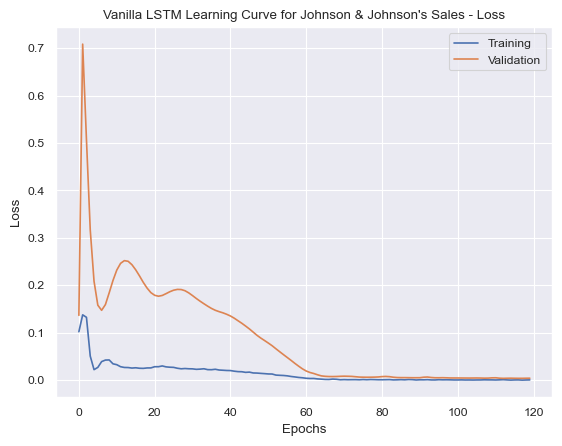

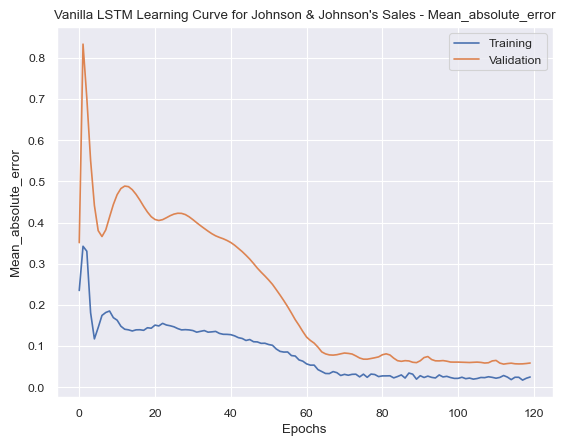

<Figure size 640x480 with 0 Axes>

In [68]:
# plotting the learning curve
plot_learning_curve(
    lstm_history, "Vanilla LSTM Learning Curve for Johnson & Johnson's Sales")

##### Forecasting For 24 Months with Roll Back  

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


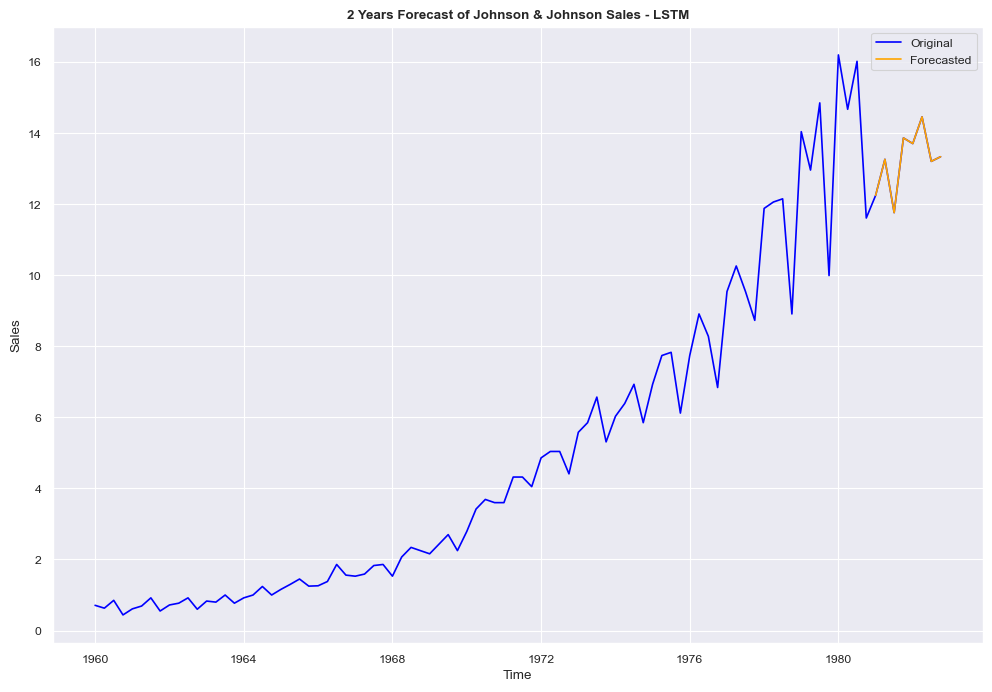

In [69]:
# forecasting and plotting
lstm_data_forecast = forecast(lstm_model, data=scaled_data.copy())
plot_forecast(pd.DataFrame(data=scaler.inverse_transform(lstm_data_forecast),
                           columns=["data"], index=lstm_data_forecast.index), "LSTM")

#### GRU 

##### Optimizing
The optimization based on bayesian method using a probabilistic model. 

In [70]:
# searching for the optimal parameter
gru_tuner, gru_best_parameter, gru_model = hypermodel_build(vanilla_gru_hypermodel(), x_train,
                                                            x_test, y_train, y_test, "Vanilla_GRU")

Trial 10 Complete [00h 00m 53s]
val_loss: 0.16710278888543448

Best val_loss So Far: 0.0005684721885093799
Total elapsed time: 00h 06m 17s
Results summary
Results in D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\HPO\Vanilla_GRU
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 02 summary
Hyperparameters:
gru_units1: 235
activation1: tanh
dropout1: False
gru1: False
learning_rate: 0.01599424268611924
optimizer: Adam
rate1: 0.6000000000000001
batch_size: 24
gru_units2: 35
activation2: sigmoid
dropout2: True
gru_units3: 40
activation3: tanh
dropout3: False
Score: 0.0005684721885093799

Trial 08 summary
Hyperparameters:
gru_units1: 85
activation1: tanh
dropout1: False
gru1: False
learning_rate: 0.0017596868467902212
optimizer: Adam
rate1: 0.375
batch_size: 56
gru_units2: 35
activation2: sigmoid
dropout2: False
gru_units3: 40
activation3: sigmoid
dropout3: True
rate3: 0.675
rate2: 0.6000000000000001
Score: 0.008797983638942242

Trial 05 summary
H

##### Training with Optimal Parameter

Usages callback methods to earlystop the training, avoiding overfitting.

In [71]:
# training the model
gru_history = model_history(x_train, y_train, x_test, y_test, gru_model,
                            gru_best_parameter.values["batch_size"], 120, "gru_jj")

Epoch 1/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - loss: 0.0313 - mean_absolute_error: 0.1375 - val_loss: 0.0481 - val_mean_absolute_error: 0.1969
Epoch 2/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0015 - mean_absolute_error: 0.0342 - val_loss: 0.0082 - val_mean_absolute_error: 0.0726
Epoch 3/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 5.6378e-04 - mean_absolute_error: 0.0128 - val_loss: 0.0046 - val_mean_absolute_error: 0.0559
Epoch 4/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0023 - mean_absolute_error: 0.0462 - val_loss: 0.0034 - val_mean_absolute_error: 0.0445
Epoch 5/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0015 - mean_absolute_error: 0.0351 - val_loss: 0.0042 - val_mean_absolute_error: 0.0531
Epoch 6/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.1498e-04 - mean_absolute_error: 0.0066 - val_loss: 0.0035 - val_mean_absolute_error: 0.0490
Epoch 7/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 4.3031e-04 - mean_absolute_error: 0.0154 - va

In [72]:
# model summary
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 235)         │       174,135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 235)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           236 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523,115 (2.00 MB)

 Trainable params: 174,371 (681.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 348,744 (1.33 MB)

Plotting the learning curve

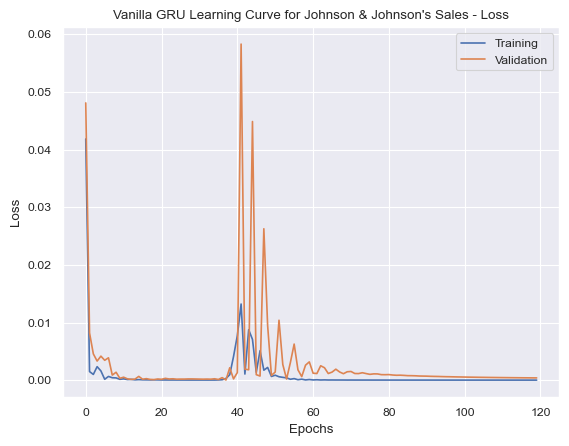

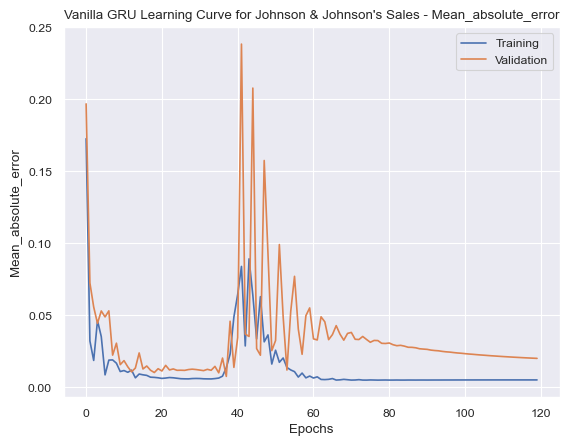

<Figure size 640x480 with 0 Axes>

In [73]:
# plotting the learning curve
plot_learning_curve(
    gru_history, "Vanilla GRU Learning Curve for Johnson & Johnson's Sales")

##### Forecasting For 24 Months with Roll Back  

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


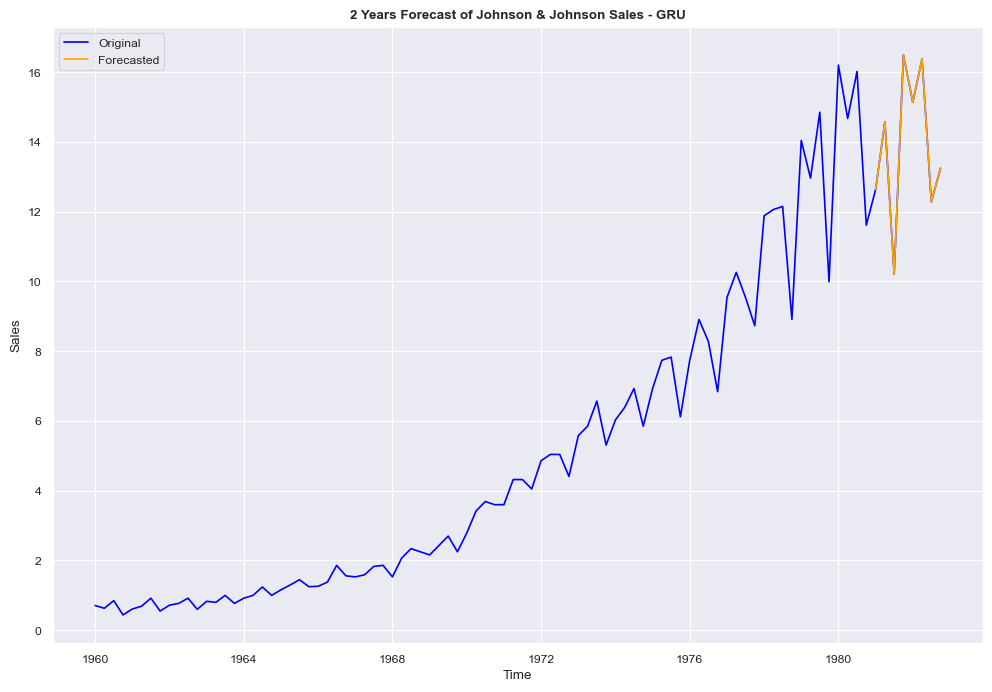

In [74]:
# forecasting and plotting
gru_data_forecast = forecast(gru_model, data=scaled_data.copy())
plot_forecast(pd.DataFrame(data=scaler.inverse_transform(gru_data_forecast),
                           columns=["data"], index=gru_data_forecast.index), "GRU")

#### LSTM-GRU

##### Optimizing
The optimization based on bayesian method using a probabilistic model. 

In [75]:
# searching for the optimal parameter
lstm_gru_tuner, lstm_gru_best_parameter, lstm_gru_model = hypermodel_build(stacked_lstm_gru_hypermodel(), x_train,
                                                                           x_test, y_train, y_test, "Vanilla_LSTM_GRU")

Trial 10 Complete [00h 00m 41s]
val_loss: 0.004519204919536908

Best val_loss So Far: 0.004519204919536908
Total elapsed time: 00h 08m 08s
Results summary
Results in D:\MScDataScience\8.Advance_Research_Topics\Assignment\Assignment2\HPO\Vanilla_LSTM_GRU
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
lstm_units1: 45
activation1: tanh
dropout1: False
gru_units1: 60
activation2: relu
dropout2: False
lstm: False
gru: False
learning_rate: 0.013161878298351373
optimizer: Adam
batch_size: 24
rate2: 0.225
gru_units2: 20
activation3: tanh
dropout3: False
rate1: 0.65
rate3: 0.675
Score: 0.004519204919536908

Trial 02 summary
Hyperparameters:
lstm_units1: 290
activation1: tanh
dropout1: True
gru_units1: 55
activation2: sigmoid
dropout2: True
lstm: False
gru: False
learning_rate: 0.0128854061025004
optimizer: Adam
batch_size: 24
rate2: 0.575
gru_units2: 50
activation3: tanh
dropout3: False
rate1: 0.2
Score: 0.011395261933406195

Trial 08 summa

##### Training with Optimal Parameter

Usages callback methods to earlystop the training, avoiding overfitting.

In [76]:
# training the model
lstm_gru_history = model_history(x_train, y_train, x_test, y_test, lstm_gru_model,
                                 lstm_gru_best_parameter.values["batch_size"], 120, "lstm_gru_jj")

Epoch 1/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 249ms/step - loss: 0.0179 - mean_absolute_error: 0.0975 - val_loss: 0.1257 - val_mean_absolute_error: 0.3379
Epoch 2/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0118 - mean_absolute_error: 0.0994 - val_loss: 0.0114 - val_mean_absolute_error: 0.0948
Epoch 3/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0269 - mean_absolute_error: 0.1543 - val_loss: 0.0214 - val_mean_absolute_error: 0.1274
Epoch 4/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0119 - mean_absolute_error: 0.0971 - val_loss: 0.0501 - val_mean_absolute_error: 0.2048
Epoch 5/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0022 - mean_absolute_error: 0.0410 - val_loss: 0.0079 - val_mean_absolute_error: 0.0697
Epoch 6/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0029 - mean_absolute_error: 0.0368 - val_loss: 0.0346 - val_mean_absolute_error: 0.1666
Epoch 7/120
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 5.8234e-04 - mean_absolute_error: 0.0168 - val_loss: 

In [77]:
# model summary
lstm_gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 45)          │        10,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 1, 60)          │        19,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,205 (344.55 KB)

 Trainable params: 29,401 (114.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,804 (229.71 KB)

Plotting the learning curve

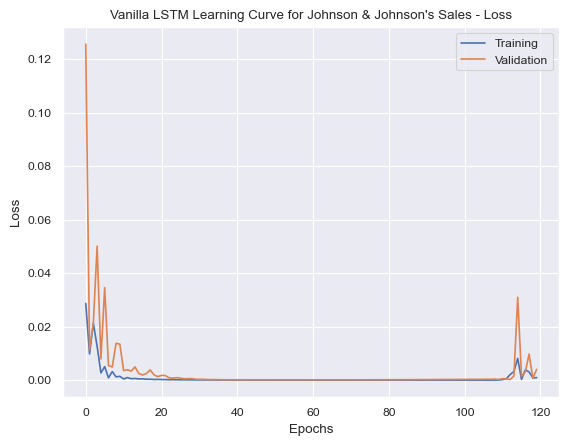

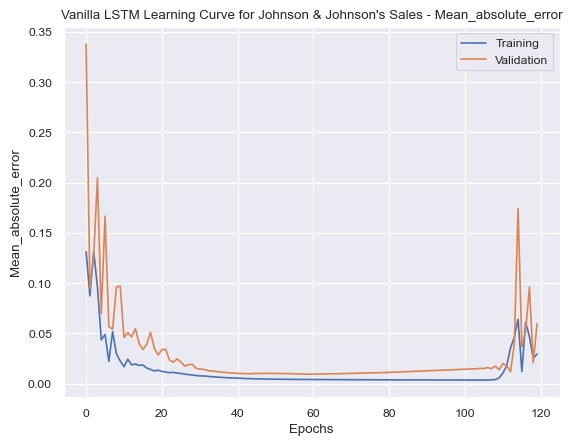

<Figure size 640x480 with 0 Axes>

In [78]:
# plotting the learning curve
plot_learning_curve(
    lstm_gru_history, "Vanilla LSTM Learning Curve for Johnson & Johnson's Sales")

##### Forecasting For 24 Months with Roll Back  

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


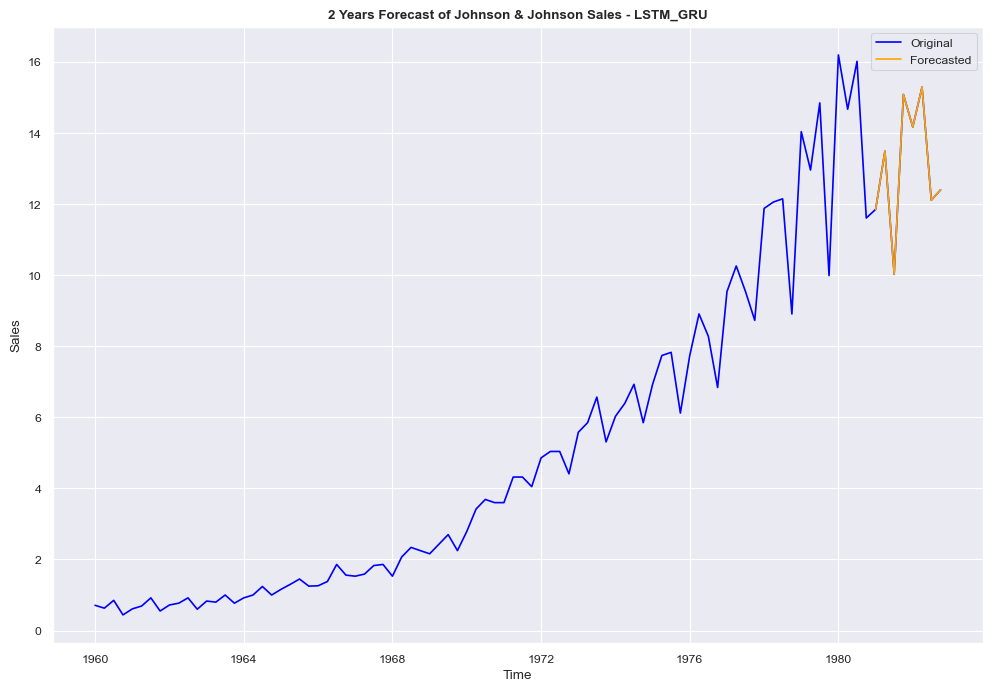

In [79]:
lstm_gru_data_forecast = forecast(lstm_gru_model, data=scaled_data.copy())
plot_forecast(pd.DataFrame(data=scaler.inverse_transform(lstm_gru_data_forecast),
                           columns=["data"], index=lstm_gru_data_forecast.index), "LSTM_GRU")

In [83]:
lstm_y_hat = lstm_model.predict(x_test)
gru_y_hat = gru_model.predict(x_test)
lstm_gru_y_hat = lstm_gru_model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


In [101]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error

rnn_metrics_df = pd.DataFrame({"MSE": [mean_squared_error(y_test, lstm_y_hat), 
                                       mean_squared_error(y_test, gru_y_hat), 
                                       mean_squared_error(y_test, lstm_gru_y_hat)],
                               "MAE": [mean_absolute_error(y_test, lstm_y_hat), 
                                       mean_absolute_error(y_test, gru_y_hat), 
                                       mean_absolute_error(y_test, lstm_gru_y_hat)],
                               "RMSE": [root_mean_squared_error(y_test, lstm_y_hat), 
                                        root_mean_squared_error(y_test, gru_y_hat), 
                                        root_mean_squared_error(y_test, lstm_gru_y_hat)]}, 
                                index=["LSTM", "GRU", "LSTM_GRU"])

In [102]:
rnn_metrics_df

,MSE,MAE,RMSE
LSTM,0.004542,0.058575,0.067398
GRU,0.000431,0.020210,0.020764
LSTM_GRU,0.004051,0.059436,0.063649


GRU among the RNN developed performs better than LSTM or LSTM-GRU stacked network.